## Experiment Workflow Test
Short notebook to validate the new experiment file workflow (`experiments/podmr.py` and `experiments/rabi.py`).

In [1]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

numpy     2.3.3
qickdawg  1.2.1
python    3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [3]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [CPMG](#cpmg)
6. [CPMG Reopt Loop](#cpmg-reopt)

<a id="laser"></a>
### Laser

In [24]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

2

In [25]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

0

### PL counts — live scope

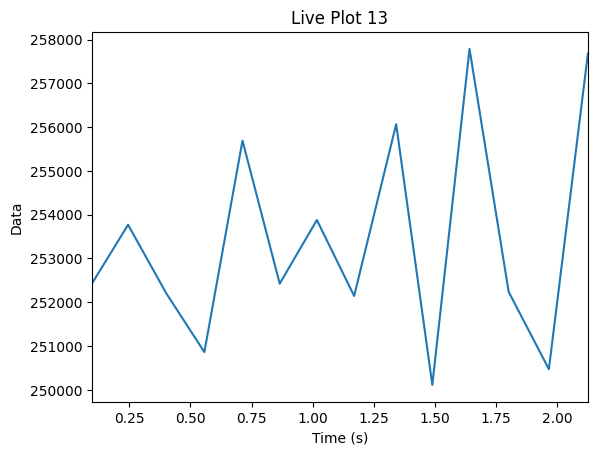

In [26]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 300
config.relax_delay_tns = 0

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / (config.readout_integration_tus * 1e-6 * config.reps)

qd.live_plot(get_cps)

<a id="podmr"></a>
### PODMR
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.


[Laser](#laser)

[config] Documented Excitation Power is 0.32 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1843.0 to 1849.0 by 0.2
Instead using 1842.9999996185302 to 1849.000011062622 by 0.20000038146972654 in 31 steps
[podmr] Sweep: 1843.000 -> 1849.000 MHz (delta 0.200 MHz)
[podmr] Active transition: lower_dip | mw_fMHz=1845.9999996185302 MHz | mw_gain=2000
[podmr] pi pulse: OVERRIDE_MW_PI_NS=679.0 ns


  0%|          | 0/3100000 [00:00<?, ?it/s]

[podmr] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260321_010108.h5
[podmr] Contrast dip fit: center=1845.913127 MHz, depth=0.42772, width=0.501333 MHz, baseline=0.995208


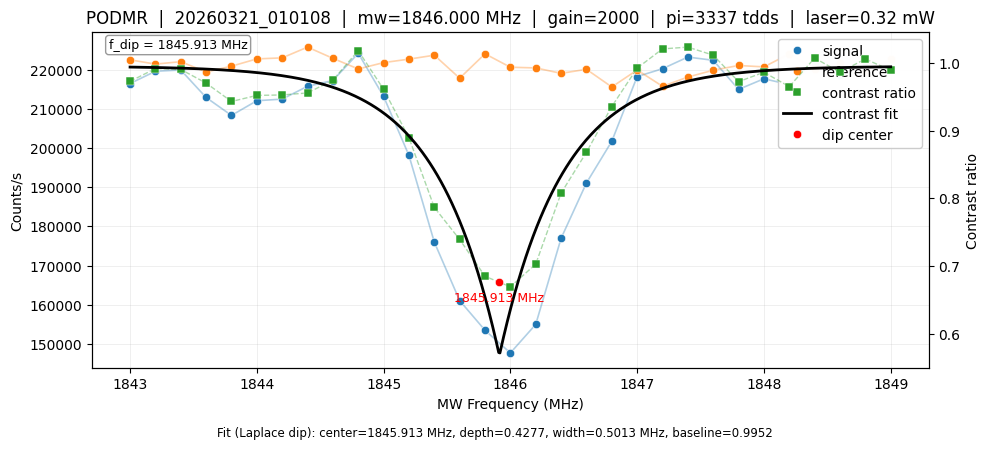

[podmr] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260321_010108.png


In [19]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

<a id="rabi"></a>
### RABI
Edit parameters in `experiments/rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser)

[config] Documented Excitation Power is 0.32 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[rabi] Sweep: 246 → 1475 tdds  (Δ 25)
[rabi] Active transition: lower_dip | freq=1845.9999996185302 MHz | gain=32767

Requested 246 to 1475 by 25
Instead using 246 to 1471 by 25 in 50


  0%|          | 0/2500000 [00:00<?, ?it/s]

[rabi] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260321_195737.h5
[rabi] Contrast fit (no decay): A=0.172779, T=107.062 ns, C=0.821035


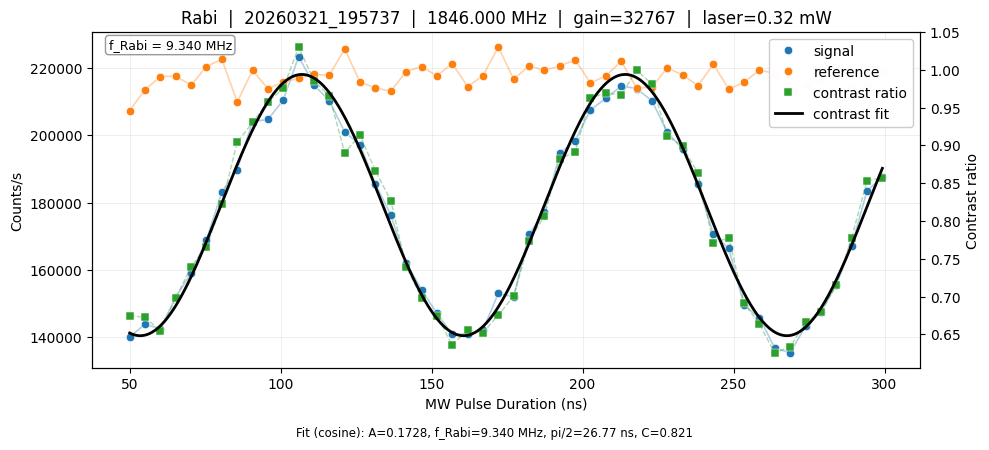

[rabi] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260321_195737.png


In [27]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/rabi.py

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser)

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/cpmg.py

[config] Documented Excitation Power is 0.32 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 8000 to 10000 by 12
Instead using 8000 to 9992 by 12 in 167
[cpmg] Sweep: 8000 -> 10000 tdds (delta 12)
[cpmg] Sweep (ns): 1627.604 -> 2034.505 ns (delta 2.441 ns)
[cpmg] Active transition: lower_dip | mw_fMHz=1845.9999996185302 MHz | mw_gain=32767
[cpmg] n_cpmg=64, mw_pi2_tdds=130, reps=7500
0b1011010


  0%|          | 0/1252500 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="cpmg-reopt"></a>
### CPMG Reopt Loop
Runs the long-loop reoptimization workflow using the regular system Python interpreter.
This avoids notebook-kernel environment mismatch for qdlutils/nidaq dependencies.

[Laser](#laser)

In [ ]:
import subprocess
from pathlib import Path
import sys
import os
import glob

# Force regular system Python environment for this workflow
SYSTEM_PYTHON = r"C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe"
SCRIPT_PATH = Path("../experiments/cpmg_reopt_loop.py")

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Could not find script: {SCRIPT_PATH.resolve()}")

cmd = [SYSTEM_PYTHON, str(SCRIPT_PATH)]
print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path("..").resolve()))

print("\n=== STDOUT (tail) ===")
stdout_lines = proc.stdout.splitlines()
for line in stdout_lines[-80:]:
    print(line)

if proc.stderr.strip():
    print("\n=== STDERR (tail) ===")
    stderr_lines = proc.stderr.splitlines()
    for line in stderr_lines[-40:]:
        print(line)

print(f"\nExit code: {proc.returncode}")
if proc.returncode != 0:
    raise RuntimeError("cpmg_reopt_loop.py failed. Check output above.")

run_dirs = sorted(glob.glob(str(Path("../data/cpmg_reopt/cpmg_reopt_run_*"))), reverse=True)
if run_dirs:
    latest = Path(run_dirs[0])
    print(f"\nLatest run dir: {latest.resolve()}")
    plots_dir = latest / "plots"
    if plots_dir.exists():
        print("Plots:")
        for p in sorted(plots_dir.glob("*.png")):
            print(f"  - {p.name}")

Launching background run: C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\python.exe -u C:\Users\QT3 User Facility\Documents\qick-dawg\experiments\cpmg_reopt_loop.py
cwd: C:\Users\QT3 User Facility\Documents\qick-dawg
log: C:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\notebook_cpmg_reopt_20260321_002249.log
Started PID 15704
State file: C:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\notebook_cpmg_reopt_state.json
Use the next cell to monitor progress and tail the log.


In [125]:
duration_s = 20*60
maxT = 10000
N = 32
step_size = 25
reps = duration_s / (maxT**2 * N * 0.2e-9 / step_size)
reps

46875.0

In [33]:
config.one_treg = 1
config.one_tns / 16

0.20345052083333334

# Miscellaneous File Reading

In [45]:
from pathlib import Path
import h5py
import numpy as np

# Combined run file relative to ../data
RUN_FILE = "cpmg_reopt/cpmg_reopt_run_20260321_010242/cpmg_xy_fine_res_combined.h5"

DATA_ROOT = Path("../data")
run_path = DATA_ROOT / RUN_FILE
if not run_path.exists():
    raise FileNotFoundError(f"Could not find: {run_path.resolve()}")

def _decode_if_bytes(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return value

def _collect_attrs(h5f):
    attrs = {}
    for k, v in h5f.attrs.items():
        attrs[k] = _decode_if_bytes(v)
    for group_name in ("experiment", "resolved_config"):
        if group_name in h5f:
            for k, v in h5f[group_name].attrs.items():
                attrs[k] = _decode_if_bytes(v)
    return attrs

def _find_dataset(datasets, names):
    for name in names:
        for k in datasets:
            if Path(k).name == name:
                return k
    return None

def _coerce_float(value):
    try:
        if value is None:
            return None
        out = float(value)
        return out if np.isfinite(out) else None
    except Exception:
        return None

def _get_tau_ns(tau_tdds, attrs, datasets):
    tau_ns_key = _find_dataset(datasets, ["tau_ns"] )
    if tau_ns_key is not None:
        tau_ns = np.asarray(datasets[tau_ns_key], dtype=float).reshape(-1)
        return tau_ns, "tau_ns dataset"

    # Prefer direct metadata conversion and use fallback if missing/invalid.
    ns_per_sample = None
    for k in ("ns_per_sample", "loop_ns_per_sample"):
        if k in attrs:
            ns_per_sample = _coerce_float(attrs[k])
            if ns_per_sample is not None:
                break

    if ns_per_sample is None:
        ns_per_sample = 0.20345052083333334
        print(
            "Warning: ns_per_sample metadata not found/invalid; using fallback "
            f"{ns_per_sample} ns/sample."
        )

    return tau_tdds * ns_per_sample, f"ns_per_sample={ns_per_sample:.9g}"

datasets = {}
with h5py.File(run_path, "r") as h5f:
    attrs = _collect_attrs(h5f)
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)

tau_key = _find_dataset(datasets, ["tau_tdds", "tau_samples", "sweep_pts"] )
signal_key = _find_dataset(datasets, ["signal1_cts_s", "signal1"] )
reference_key = _find_dataset(datasets, ["signal2_cts_s", "signal2"] )
contrast_key = _find_dataset(datasets, ["contrast"] )

if tau_key is None:
    raise KeyError("No tau dataset found (tried tau_tdds/tau_samples/sweep_pts).")
if signal_key is None or reference_key is None:
    raise KeyError("Missing signal/reference datasets in combined file.")

tau_tdds = np.asarray(datasets[tau_key], dtype=float).reshape(-1)
tau_ns, tau_ns_source = _get_tau_ns(tau_tdds, attrs, datasets)
signal = np.asarray(datasets[signal_key], dtype=float).reshape(-1)
reference = np.asarray(datasets[reference_key], dtype=float).reshape(-1)

if contrast_key is not None:
    contrast = np.asarray(datasets[contrast_key], dtype=float).reshape(-1)
else:
    contrast = signal / np.clip(reference, 1e-12, None)

print(f"Loaded combined file: {run_path.resolve()}")
print(f"tau source: {tau_key}")
print(f"tau_ns conversion: {tau_ns_source}")
print(f"signal source: {signal_key}")
print(f"reference source: {reference_key}")
print(f"contrast source: {contrast_key if contrast_key is not None else 'computed signal/reference'}")
print(f"points: tau={len(tau_ns)}, signal={len(signal)}, reference={len(reference)}, contrast={len(contrast)}")

Loaded combined file: C:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260321_010242\cpmg_xy_fine_res_combined.h5
tau source: /data/tau_tdds
tau_ns conversion: ns_per_sample=0.203450521
signal source: /data/signal1_cts_s
reference source: /data/signal2_cts_s
contrast source: /data/contrast
points: tau=761, signal=761, reference=761, contrast=761


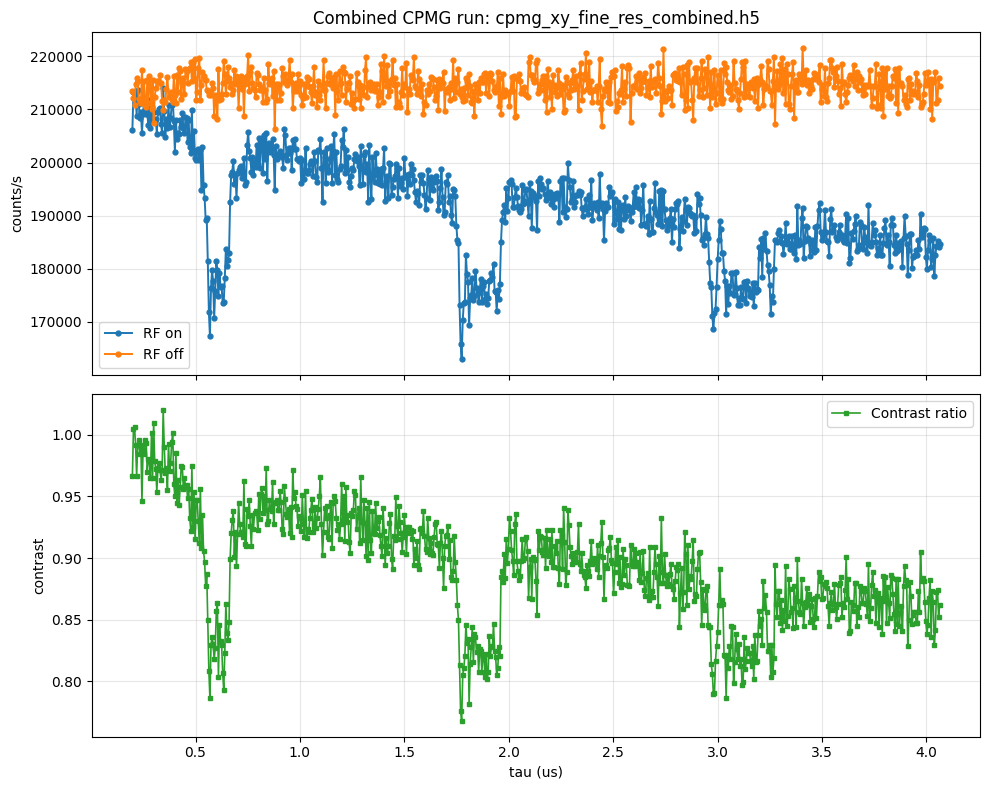

Plotted 761 signal points, 761 reference points, 761 contrast points vs tau (ns).


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Requires variables produced by the previous cell:
# tau_ns, signal, reference, contrast, run_path
required_vars = ["tau_ns", "signal", "reference", "contrast", "run_path"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous combined-data extraction cell first. Missing: {missing}")

x = np.asarray(tau_ns/1e3, dtype=float).reshape(-1)
y_sig = np.asarray(signal, dtype=float).reshape(-1)
y_ref = np.asarray(reference, dtype=float).reshape(-1)
y_con = np.asarray(contrast, dtype=float).reshape(-1)

n_sig = min(len(x), len(y_sig))
n_ref = min(len(x), len(y_ref))
n_con = min(len(x), len(y_con))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x[:n_sig], y_sig[:n_sig], "o-", lw=1.4, ms=3.5, label="RF on")
ax1.plot(x[:n_ref], y_ref[:n_ref], "o-", lw=1.4, ms=3.5, label="RF off")
ax1.set_ylabel("counts/s")
ax1.set_title(f"Combined CPMG run: {run_path.name}")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x[:n_con], y_con[:n_con], "s-", lw=1.2, ms=3.2, color="tab:green", label="Contrast ratio")
ax2.set_xlabel("tau (us)")
ax2.set_ylabel("contrast")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {n_sig} signal points, {n_ref} reference points, {n_con} contrast points vs tau (ns).")

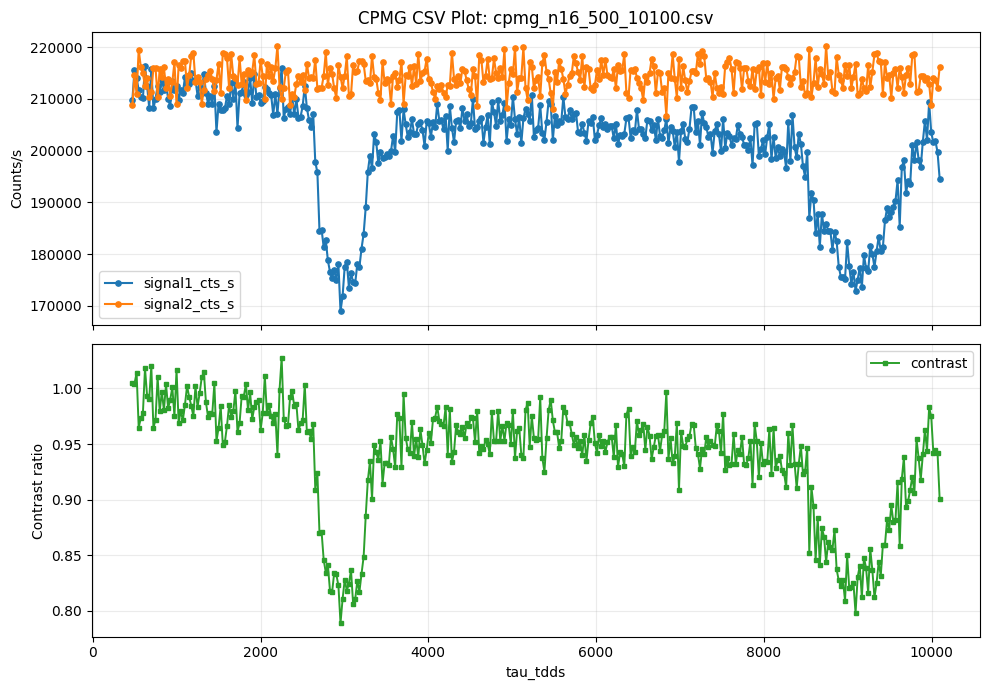

Plotted 385 rows from cpmg_n16_500_10100.csv


In [73]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path("cpmg_n16_500_10100.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {csv_path.resolve()}")

df = pd.read_csv(csv_path)

required = ["tau_tdds", "signal1_cts_s", "signal2_cts_s", "contrast"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

tau_tdds = df["tau_tdds"].to_numpy(dtype=float)
signal = df["signal1_cts_s"].to_numpy(dtype=float)
reference = df["signal2_cts_s"].to_numpy(dtype=float)
contrast = df["contrast"].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(tau_tdds, signal, "o-", lw=1.5, ms=3.8, label="signal1_cts_s")
ax1.plot(tau_tdds, reference, "o-", lw=1.5, ms=3.8, label="signal2_cts_s")
ax1.set_ylabel("Counts/s")
ax1.set_title(f"CPMG CSV Plot: {csv_path.name}")
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(tau_tdds, contrast, "s-", lw=1.4, ms=3.5, color="tab:green", label="contrast")
ax2.set_xlabel("tau_tdds")
ax2.set_ylabel("Contrast ratio")
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {len(df)} rows from {csv_path}")